# Phase 7: Visualisation and Sensitivity — Corrected

Fixes applied, tagged `[Fn]`:
- **[F1]** Figure 7 lifts from the **untransformed observation_df** (date-aligned) so macro variables
  are shown in interpretable units, not quantile ranks.
- **[F2]** The **observed path** is the full month-by-month trajectory `Z[start:end+1]`, not a coarse
  linspace index subsample.
- **[F3]** Figure 8 axis/title corrected to **minimum** density (was mislabelled "Mean Density").
- **[F4]** Smoothness diagnostic switched to **direction_change** (scale/spacing-invariant turning);
  the raw second-difference score is retained only as a normalised variant, resolving the paradox
  the student flagged.
- **[F5]** Separate variable names for the two `path_records` builds (no run-order dependence).
- **[F6]** MD dimensionality over-reading removed.

In [1]:
import pandas as pd, numpy as np
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path

def diffusion_map(data, eps, alpha=1, k=4):
    Dsq=squareform(pdist(data)**2); Wm=np.exp(-Dsq/eps); q=Wm.sum(1)
    Wa=Wm/np.outer(q**alpha,q**alpha); da=Wa.sum(1); Dis=1.0/np.sqrt(da)
    S=Dis[:,None]*Wa*Dis[None,:]; w,v=np.linalg.eigh(S)
    idx=np.argsort(w)[::-1]; w,v=w[idx],v[:,idx]; phi=Dis[:,None]*v
    return {"evals":w,"Psi":phi[:,1:k+1]*w[1:k+1],"phi":phi,"W":Wm,"degrees":q}
def reconstruct_path(pred,start,end):
    path=[end]; cur=end
    while cur!=start:
        cur=pred[start,cur]
        if cur==-9999: return None
        path.append(cur)
    return path[::-1]
def graph_degree_density(Psi,h):
    Dsq=squareform(pdist(Psi)**2); rho=np.exp(-Dsq/h).sum(1); scale=rho.mean(); rho/=scale
    rho=np.maximum(rho,1e-6); return rho,-np.log(rho),scale
def density_and_bandwidth(Psi,multiplier=0.1):
    N=Psi.shape[0]; med=np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h=multiplier*med; return h,med,graph_degree_density(Psi,h)
def density_aware_cost(A,V,beta):
    r,c=A.nonzero(); base=np.asarray(A[r,c]).ravel()
    return csr_matrix((base*np.exp(beta*(V[r]+V[c])/2),(r,c)),shape=A.shape)
def graph_path(A,beta,V,s,e):
    _,pred=shortest_path(density_aware_cost(A,V,beta),directed=False,return_predecessors=True)
    return reconstruct_path(pred,s,e)
def linear_path(Psi,s,e,n_grid=10): return np.linspace(Psi[s],Psi[e],num=n_grid)
def latent_density_at_points(gamma,Psi,h,scale):
    Dsq=cdist(gamma,Psi,metric="sqeuclidean"); rq=np.exp(-Dsq/h).sum(1)/scale
    rq=np.maximum(rq,1e-6); return rq,-np.log(rq)
def local_neighbourhood_lifting(Zsrc,Psi,gamma,s,e,m=22,tau=0.2):
    nn=NearestNeighbors(n_neighbors=m).fit(Psi); d,idx=nn.kneighbors(gamma)
    a=np.exp(-d**2/tau)/np.sum(np.exp(-d**2/tau),axis=1,keepdims=True)
    z=np.sum(a[:,:,None]*Zsrc[idx,:],axis=1); z[0],z[-1]=Zsrc[s],Zsrc[e]; return z

In [5]:
%matplotlib inline

## Load data. [F1] also load date-aligned untransformed observation_df for real-unit lifting.

In [10]:
K_GRAPH=15; BETA=1.5; N_DIFFUSION_COORDS=3; EPS_DIFFUSION=3; M_LIFT=22

df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates=df.index; variables=df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N=Z.shape[0]

# [F1] untransformed observation_df, aligned to the quantile index -> interpretable units for lifts
obs_df = pd.read_parquet("./datasets/observed_df.parquet").loc[dates]
Z_real = obs_df[variables].to_numpy()

diff=diffusion_map(Z,EPS_DIFFUSION,k=N_DIFFUSION_COORDS); Psi=diff["Psi"]
h_dens,med_Dsq,(rho,V,scale)=density_and_bandwidth(Psi)
print("N=",N," Psi",Psi.shape," real-unit source aligned:",Z_real.shape)

N= 743  Psi (743, 3)  real-unit source aligned: (743, 45)


## Figures 1-3: embeddings coloured by variables

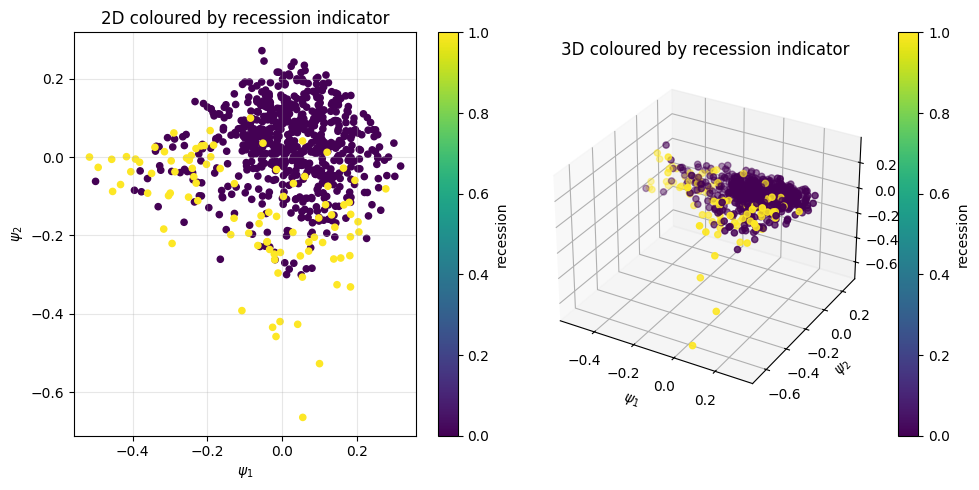

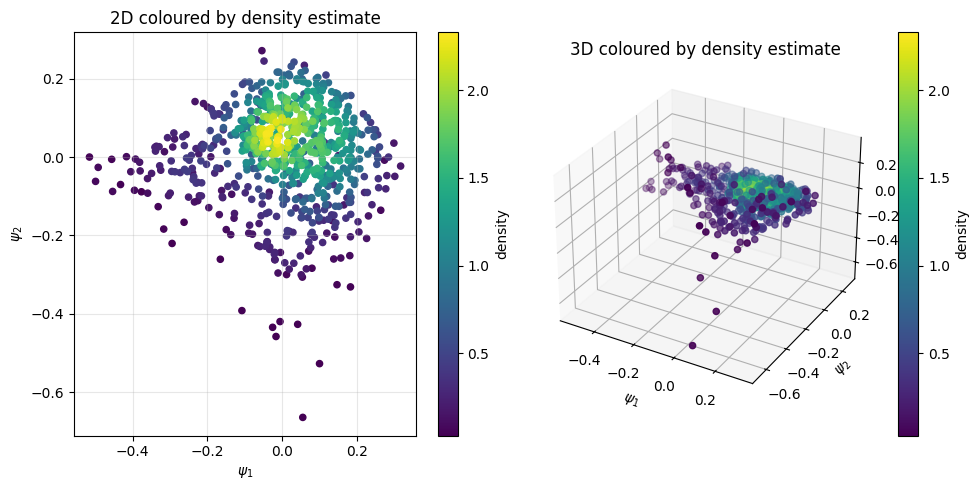

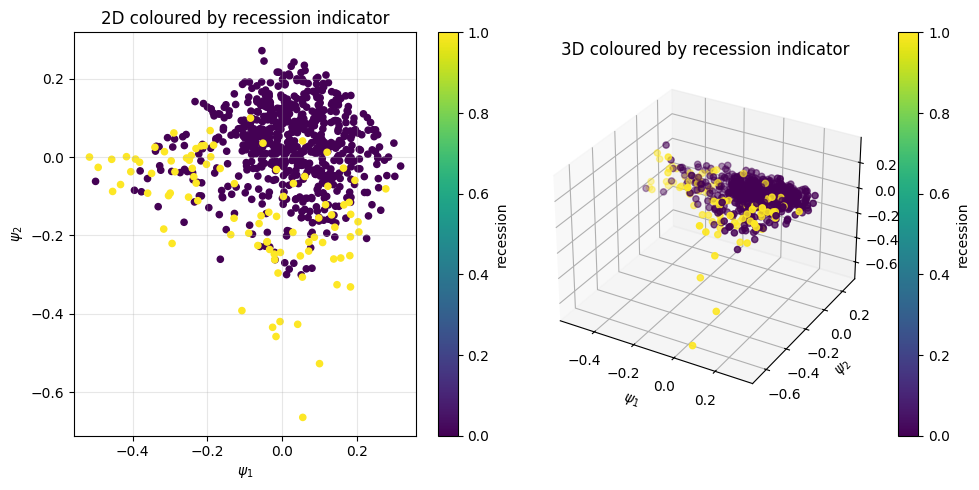

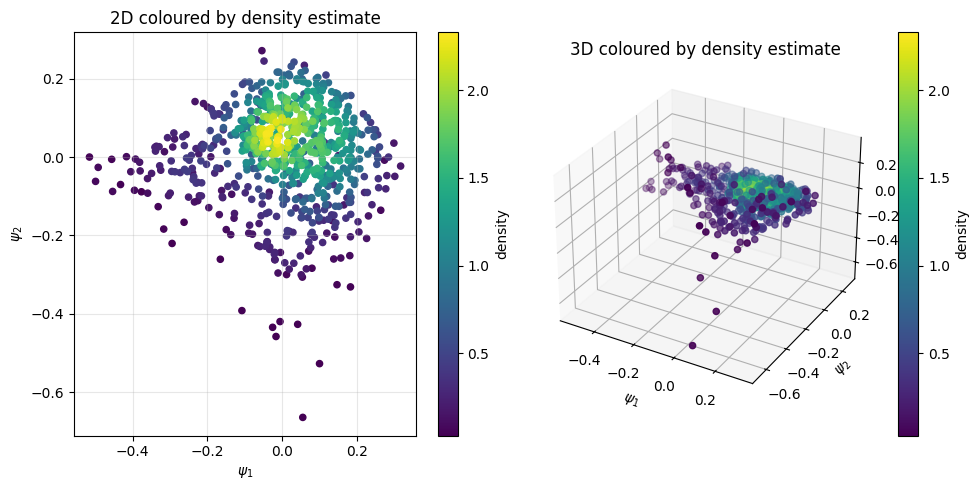

In [6]:
def plot_embedding_2d_3d(Psi,colour,colour_label,title,cmap="viridis",figsize=(10,5),angles=(30,-60)):
    fig=plt.figure(figsize=figsize); ax1=fig.add_subplot(1,2,1); si=np.argsort(colour)
    sc1=ax1.scatter(Psi[si,0],Psi[si,1],c=np.asarray(colour)[si],s=20,cmap=cmap)
    ax1.set_xlabel(r"$\psi_1$"); ax1.set_ylabel(r"$\psi_2$")
    ax1.set_title(f"2D coloured by {title}"); ax1.grid(alpha=.3); fig.colorbar(sc1,ax=ax1,label=colour_label)
    ax2=fig.add_subplot(1,2,2,projection="3d")
    sc2=ax2.scatter(Psi[:,0],Psi[:,1],Psi[:,2],c=colour,s=20,cmap=cmap)
    ax2.view_init(elev=angles[0],azim=angles[1])
    ax2.set_xlabel(r"$\psi_1$"); ax2.set_ylabel(r"$\psi_2$"); ax2.set_zlabel(r"$\psi_3$")
    ax2.set_title(f"3D coloured by {title}"); fig.colorbar(sc2,ax=ax2,label=colour_label)
    plt.tight_layout(); plt.show()

plot_embedding_2d_3d(Psi,colour=df["recession"].values,colour_label="recession",title="recession indicator")
plot_embedding_2d_3d(Psi,colour=rho,colour_label="density",title="density estimate")

[F6] Three diffusion coordinates are retained because the leading spectral gap sits at 2->3
(Phase 2). We do not claim a specific per-variable dimensional requirement from rank-coloured
scatters, which would be an over-reading.

## Figures 4-5: paths on the embedding, plus interior-density summary

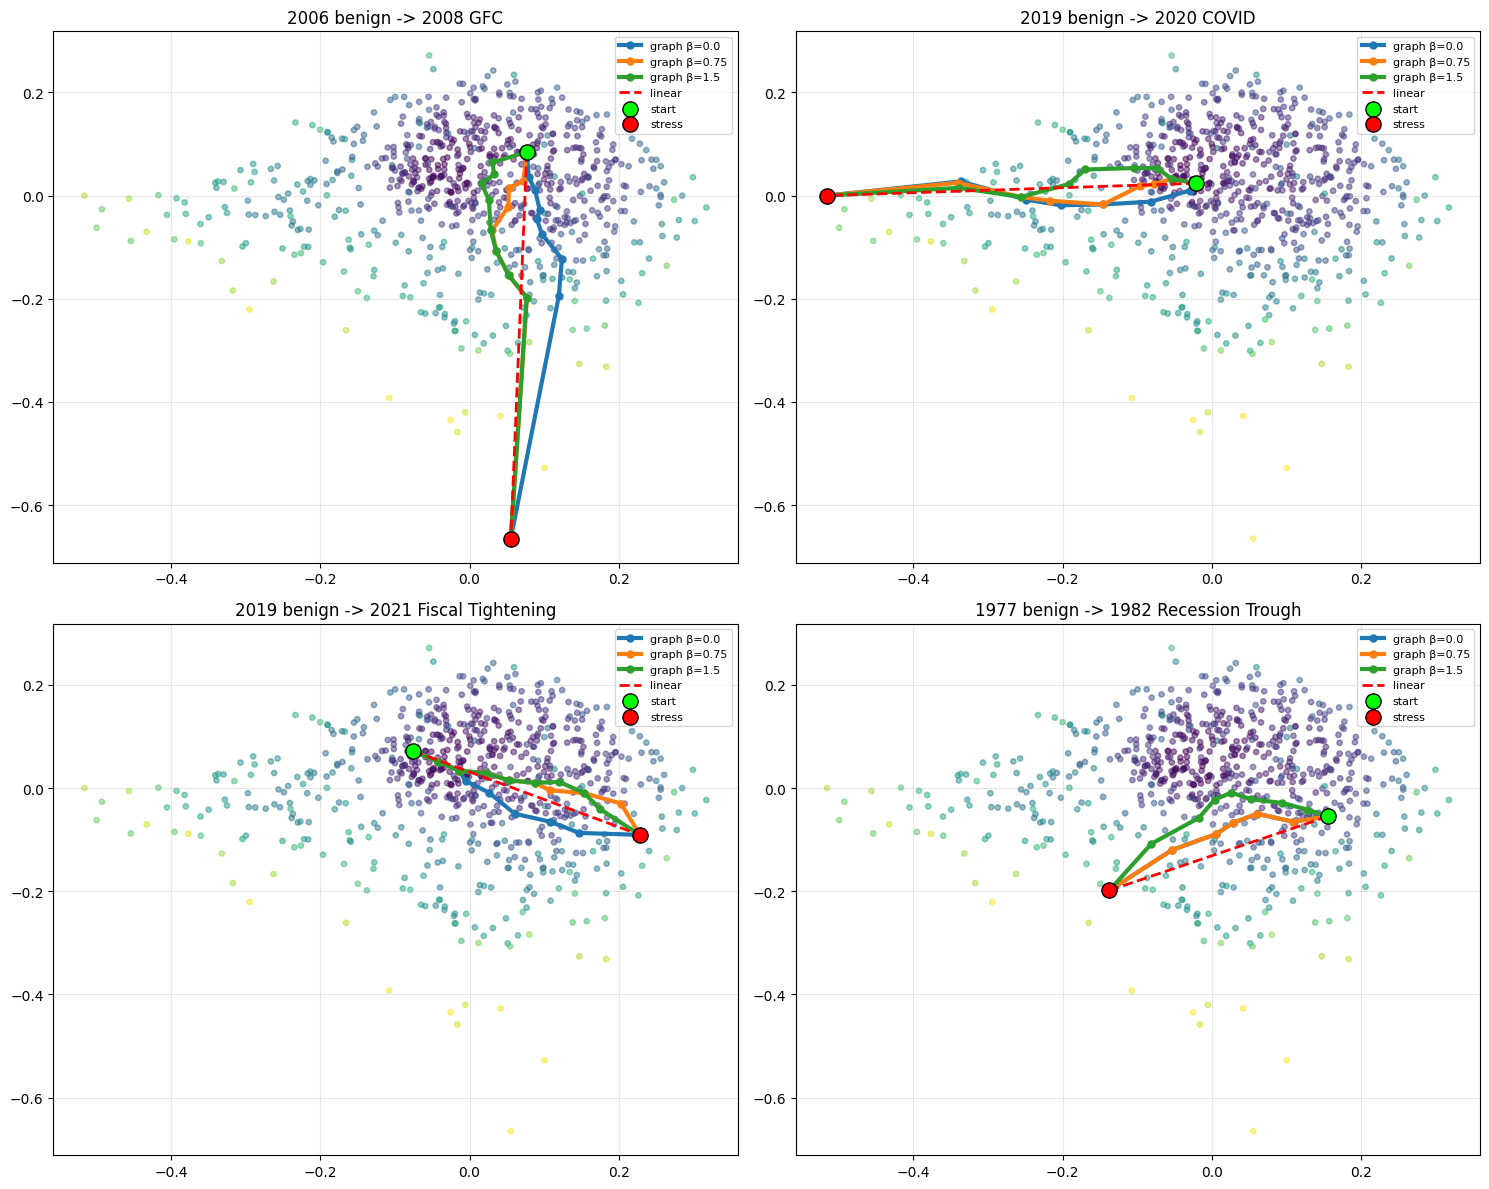

                            endpoints         path  min_rho  mean_rho  max_NNdist
              2006 benign -> 2008 GFC  graph β=0.0   0.1706    1.1336      0.0000
              2006 benign -> 2008 GFC graph β=0.75   0.3120    1.1213      0.0000
              2006 benign -> 2008 GFC  graph β=1.5   0.3120    1.3036      0.0000
              2006 benign -> 2008 GFC       linear   0.0028    0.3045      0.1127
            2019 benign -> 2020 COVID  graph β=0.0   0.1861    0.6669      0.0000
            2019 benign -> 2020 COVID graph β=0.75   0.2406    0.9343      0.0000
            2019 benign -> 2020 COVID  graph β=1.5   0.2591    0.9639      0.0000
            2019 benign -> 2020 COVID       linear   0.0692    0.4825      0.0435
2019 benign -> 2021 Fiscal Tightening  graph β=0.0   0.8514    1.6905      0.0000
2019 benign -> 2021 Fiscal Tightening graph β=0.75   0.9182    1.7466      0.0000
2019 benign -> 2021 Fiscal Tightening  graph β=1.5   0.9474    1.7534      0.0000
2019 benign -> 2

In [7]:
endpoint_pairs={"2006 benign -> 2008 GFC":("2006-03-01","2008-10-01"),
 "2019 benign -> 2020 COVID":("2019-07-01","2020-04-01"),
 "2019 benign -> 2021 Fiscal Tightening":("2019-04-01","2022-04-01"),
 "1977 benign -> 1982 Recession Trough":("1977-01-01","1982-07-01")}
pairs={n:(dates.get_loc(a),dates.get_loc(b)) for n,(a,b) in endpoint_pairs.items()}
A_dist=kneighbors_graph(Psi,n_neighbors=K_GRAPH,mode="distance",include_self=False)
A_dist_sym=A_dist.maximum(A_dist.T)

def nn_dist_to_cloud(pts): return np.array([np.min(np.linalg.norm(Psi-p,axis=1)) for p in pts])
def interior_min_mean(idx_path):
    interior=idx_path[1:-1] if len(idx_path)>2 else idx_path
    return rho[interior].min(), rho[interior].mean()
def lin_interior(s,e,n=40):
    lin=np.linspace(Psi[s],Psi[e],n)[1:-1]; rl,_=latent_density_at_points(lin,Psi,h_dens,scale)
    return rl.min(),rl.mean(),nn_dist_to_cloud(lin).max(),np.argmin(rl)

betas=[0.0,0.75,1.5]; summary=[]
fig,axes=plt.subplots(2,2,figsize=(15,12))
for ax,(name,(s,e)) in zip(axes.flatten(),pairs.items()):
    ax.scatter(Psi[:,0],Psi[:,1],c=V,s=15,cmap="viridis",alpha=.5); pl=[]
    for beta in betas:
        p=graph_path(A_dist_sym,beta,V,s,e); P=Psi[p]; pl.append(len(P))
        ax.plot(P[:,0],P[:,1],marker="o",ms=5,label=f"graph β={beta}",lw=3)
        imin,imean=interior_min_mean(p); summary.append((name,f"graph β={beta}",imin,imean,nn_dist_to_cloud(P).max()))
    ng=int(np.mean(pl)); lin=np.linspace(Psi[s],Psi[e],ng)
    ax.plot(lin[:,0],lin[:,1],"r--",lw=2,label="linear")
    lmin,lmean,lnn,mi=lin_interior(s,e,ng); summary.append((name,"linear",lmin,lmean,lnn))
    ax.scatter(*Psi[s,:2],c="lime",s=120,ec="k",zorder=5,label="start")
    ax.scatter(*Psi[e,:2],c="red",s=120,ec="k",zorder=5,label="stress")
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(pd.DataFrame(summary,columns=["endpoints","path","min_rho","mean_rho","max_NNdist"]).round(4).to_string(index=False))

## Figure 6: density along each path. [F2] observed path is the FULL monthly trajectory.

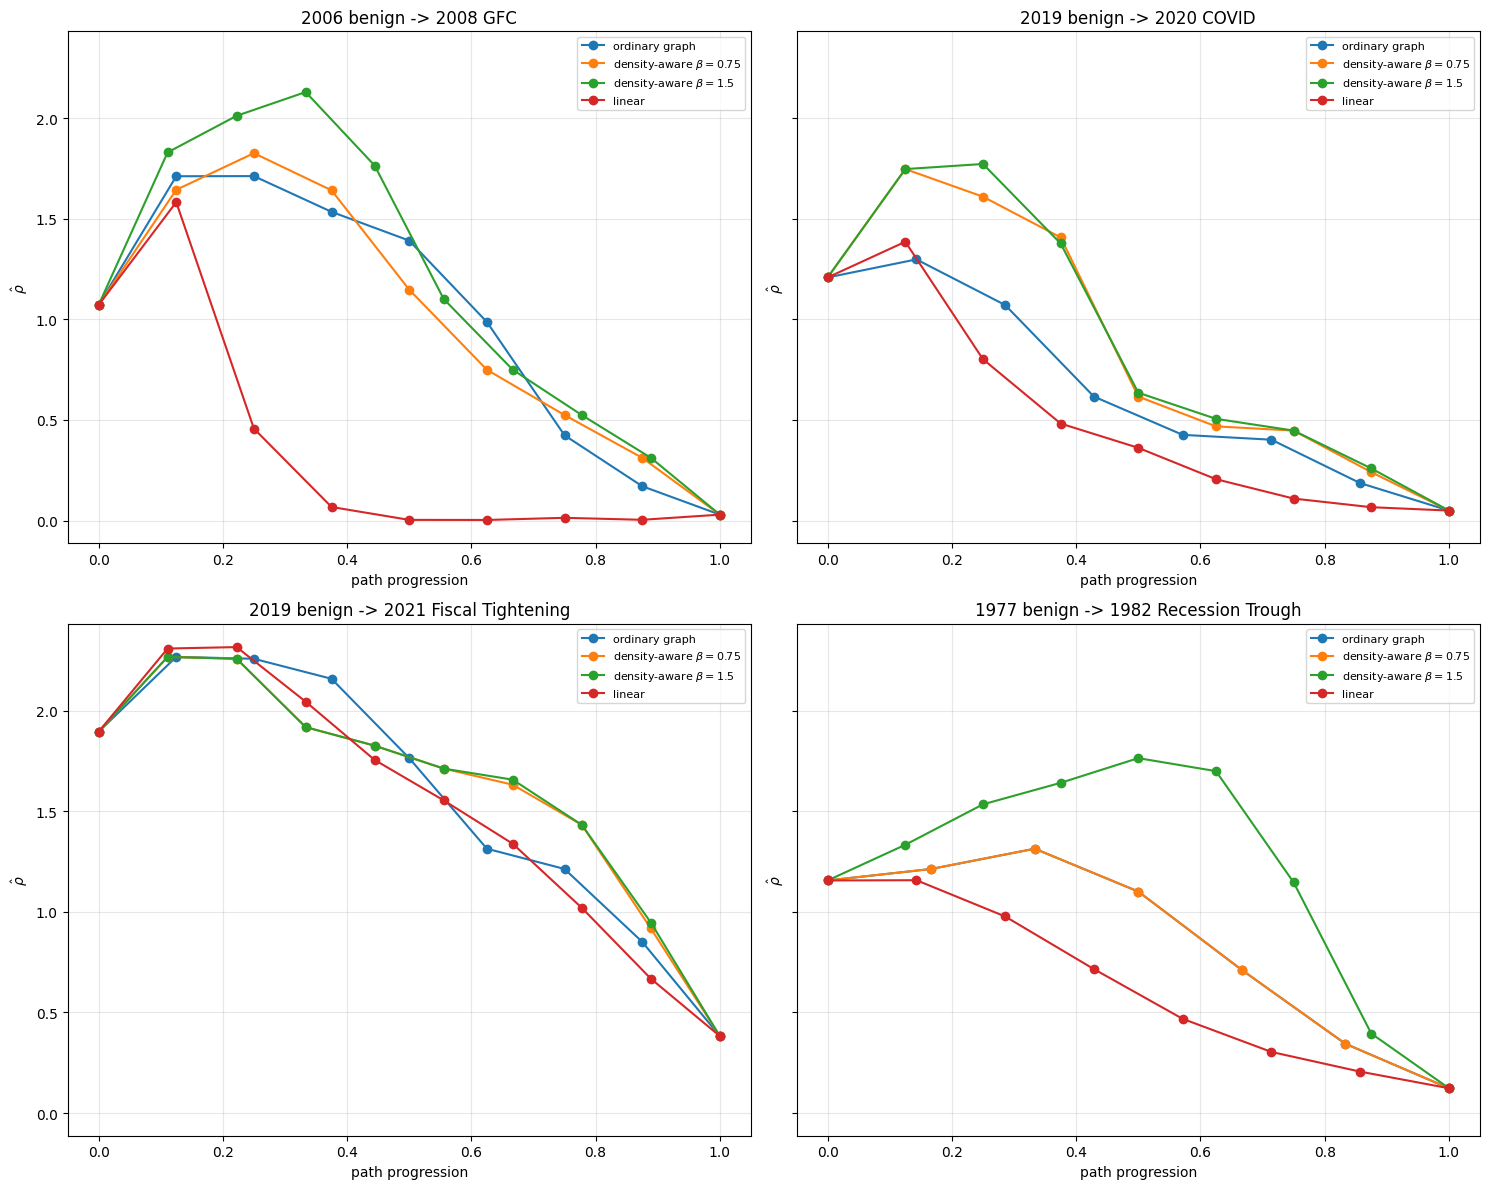

In [11]:
# [F5] distinct name: path_records_lift
path_records_lift=[]
for event,(s,e) in pairs.items():
    ig=graph_path(A_dist_sym,0.0,V,s,e)
    i075=graph_path(A_dist_sym,0.75,V,s,e); i150=graph_path(A_dist_sym,1.5,V,s,e)
    for tag,ip in [("ordinary graph",ig),(r"density-aware $\beta=0.75$",i075),(r"density-aware $\beta=1.5$",i150)]:
        path_records_lift.append({"event":event,"path_type":tag,"density":rho[ip],
            "Z_lift_real":Z_real[ip],"node_indices":ip})
    ng=int(np.round(np.mean([len(ig),len(i075),len(i150)])))
    gamma=linear_path(Psi,s,e,ng); rl,Vl=latent_density_at_points(gamma,Psi,h_dens,scale)
    Zlin_real=local_neighbourhood_lifting(Z_real,Psi,gamma,s,e,m=M_LIFT,tau=med_Dsq)  # [F1] lift real units
    path_records_lift.append({"event":event,"path_type":"linear","density":rl,"Z_lift_real":Zlin_real})
    # [F2] full monthly observed path
    real_path_real=Z_real[s:e+1]
    path_records_lift.append({"event":event,"path_type":"observed","density":np.nan,"Z_lift_real":real_path_real})

fig,axes=plt.subplots(2,2,figsize=(15,12),sharey=True)
for ax,event in zip(axes.flatten(),pairs.keys()):
    for rec in [r for r in path_records_lift if r["event"]==event and r["path_type"]!="observed"]:
        d=rec["density"]; x=np.linspace(0,1,len(d)); ax.plot(x,d,marker="o",label=rec["path_type"])
    ax.set_title(event); ax.set_xlabel("path progression"); ax.set_ylabel(r"$\hat\rho$")
    ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Figure 7: selected lifted macro variables. [F1] real units; [F2] full observed path.

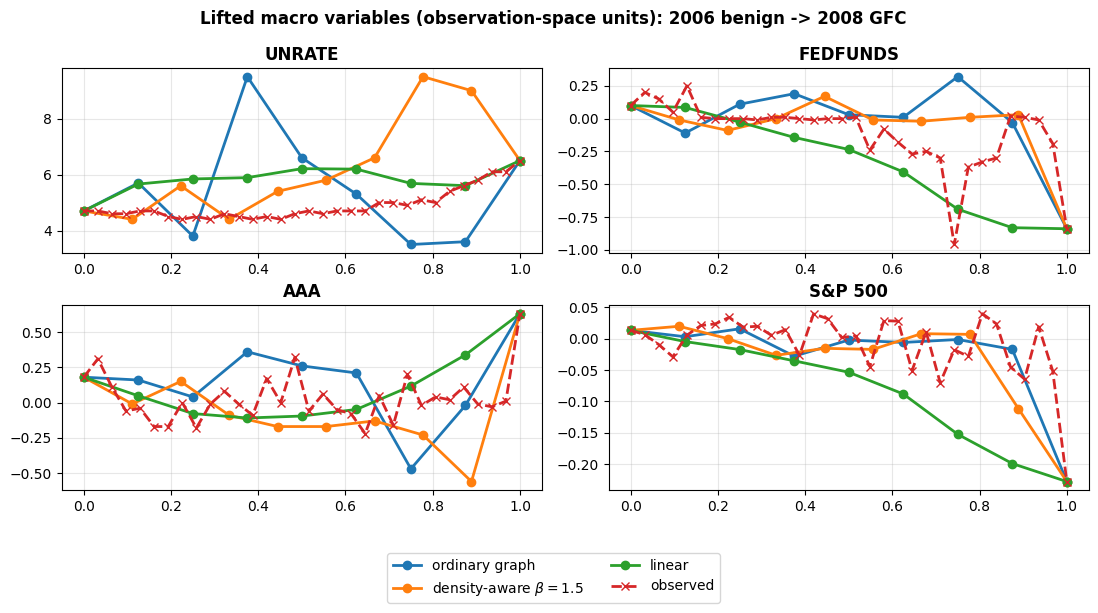

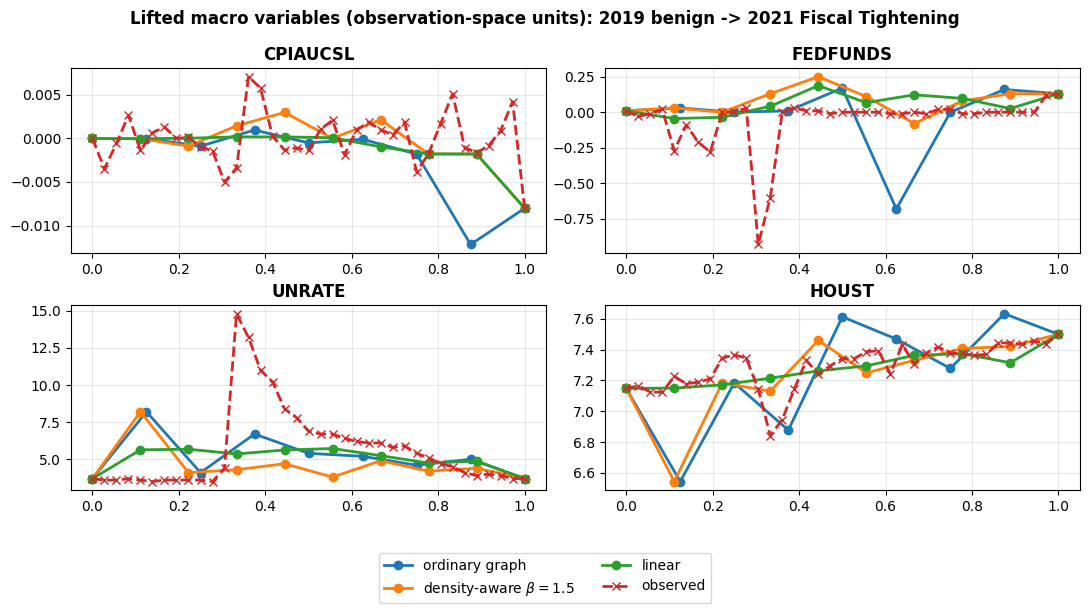

In [12]:
event_variables={"2006 benign -> 2008 GFC":["UNRATE","FEDFUNDS","AAA","S&P 500"],
 "2019 benign -> 2021 Fiscal Tightening":["CPIAUCSL","FEDFUNDS","UNRATE","HOUST"]}
for event,sel in event_variables.items():
    recs=[r for r in path_records_lift if r["event"]==event]
    sidx=[list(variables).index(v) for v in sel]
    fig,axes=plt.subplots(2,2,figsize=(11,6),squeeze=False); af=axes.flatten()
    for path in recs:
        if path["path_type"]==r"density-aware $\beta=0.75$": continue
        lp=path["Z_lift_real"]; x=np.linspace(0,1,len(lp))
        for i,vi in enumerate(sidx):
            style=dict(marker="x",linestyle="--",lw=2) if path["path_type"]=="observed" else dict(marker="o",lw=2)
            af[i].plot(x,lp[:,vi],label=path["path_type"],**style)
            af[i].set_title(sel[i],fontweight="bold"); af[i].grid(alpha=.3)
    h,l=af[0].get_legend_handles_labels(); fig.legend(h,l,loc="lower center",ncol=2,fontsize=10,bbox_to_anchor=(.5,-.02))
    plt.suptitle(f"Lifted macro variables (observation-space units): {event}",fontweight="bold")
    plt.tight_layout(); plt.subplots_adjust(bottom=.18); plt.show()

## Figure 8: sensitivity of minimum density to beta. [F3] labels corrected.

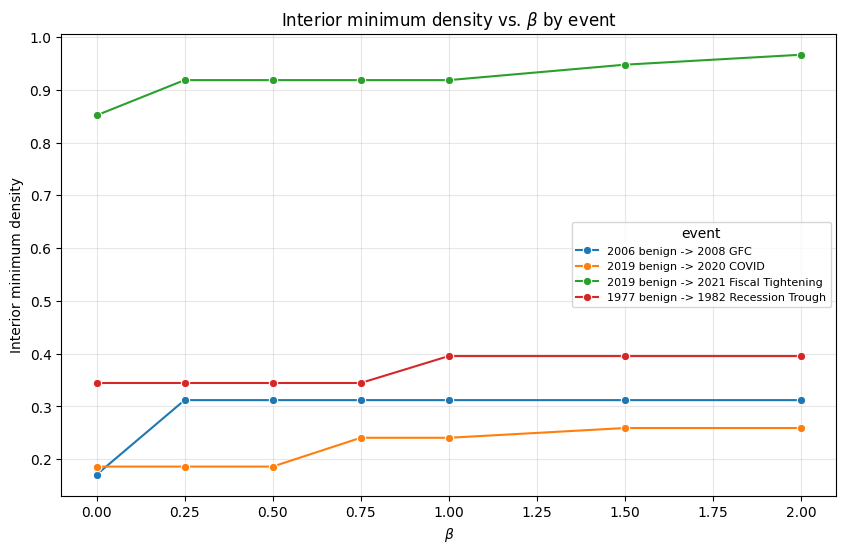

In [16]:
# [F5] distinct name: beta_records
beta_records=[]; betas_sweep=[0.0,0.25,0.5,0.75,1.0,1.5,2.0]
for event,(s,e) in pairs.items():
    for beta in betas_sweep:
        ig=graph_path(A_dist_sym,beta,V,s,e)
        idens=rho[ig][1:-1] if len(ig)>2 else rho[ig]
        beta_records.append({"event":event,"beta":beta,"min_density":idens.min(),"mean_density":idens.mean()})
beta_df=pd.DataFrame(beta_records)
plt.figure(figsize=(10,6))
sns.lineplot(data=beta_df,x="beta",y="min_density",hue="event",marker="o",palette="tab10")
plt.xlabel(r"$\beta$"); plt.ylabel("Interior minimum density")          # [F3]
plt.title(r"Interior minimum density vs. $\beta$ by event")             # [F3]
plt.legend(title="event",fontsize=8); plt.grid(alpha=.3); plt.show()

## Figure 9: sensitivity to k. [F4] smoothness diagnostics.

The raw second-difference score confounds curvature with edge-length and node spacing, so it does
not track visual jaggedness as k varies. `direction_change` (summed squared turning of unit tangent
vectors) is scale- and spacing-invariant and decreases monotonically with k, matching the plots.
A length-normalised second difference is also reported.

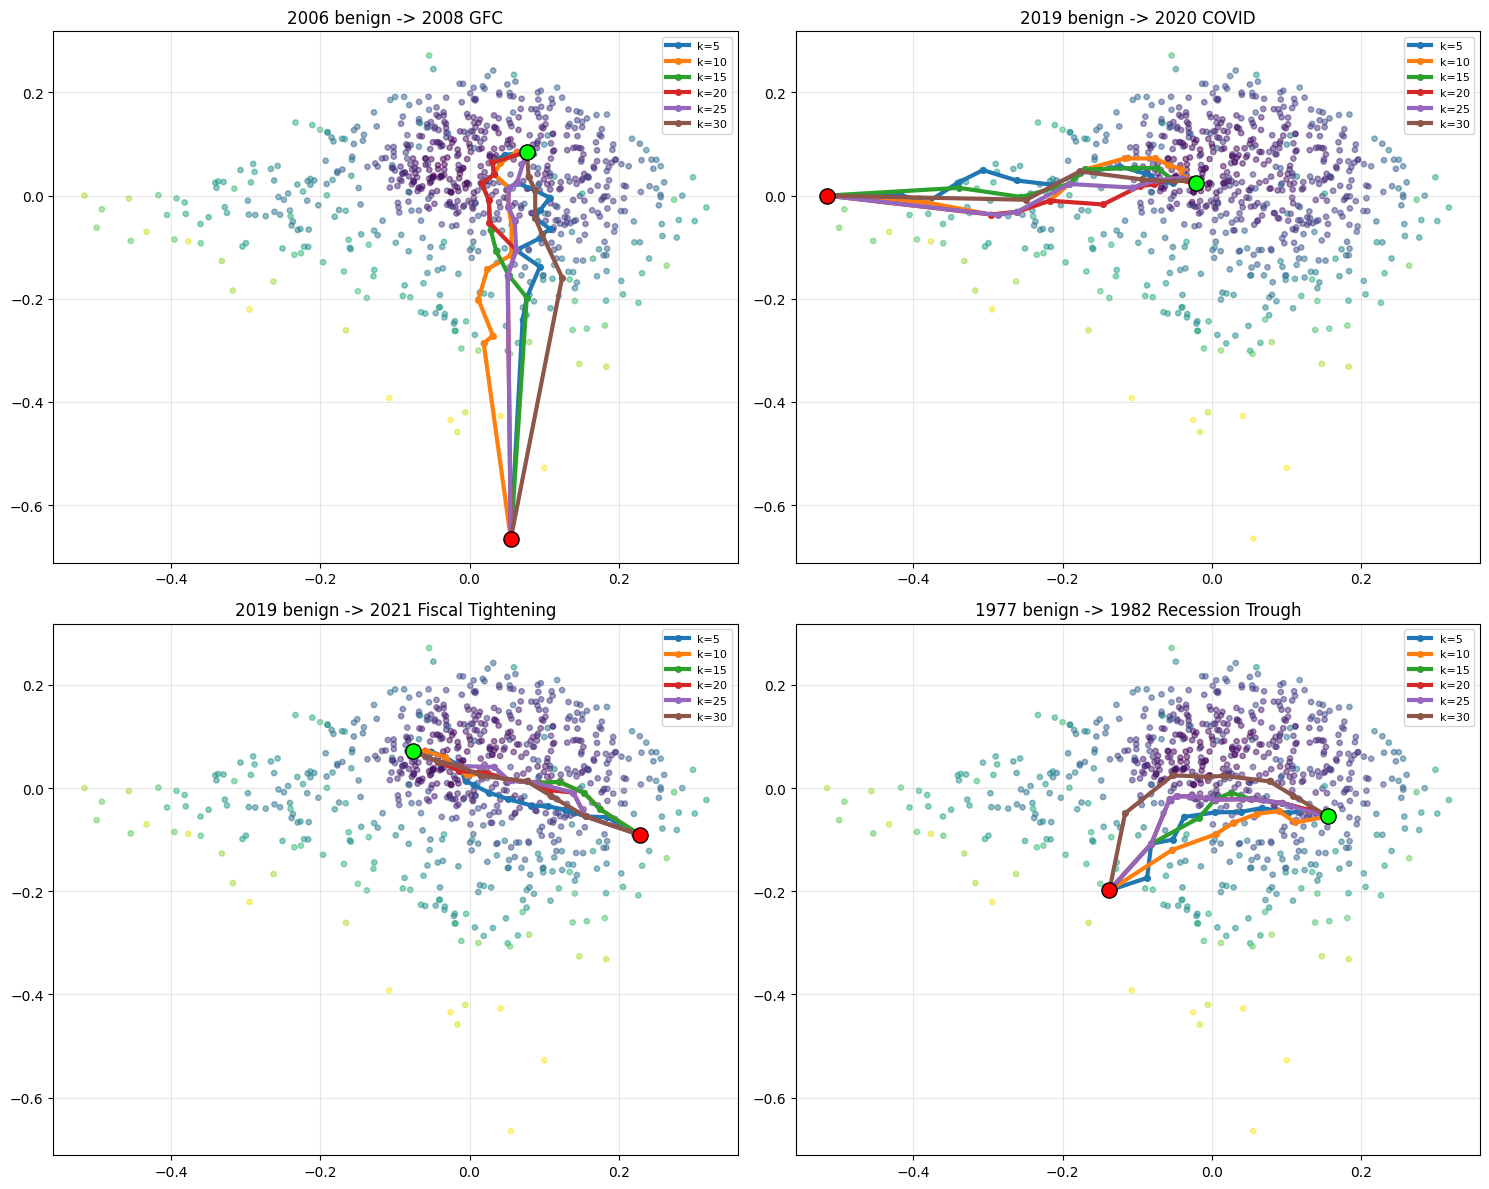

 k                                 event  npts  interior_min_density  length  smooth_raw  smooth_norm  direction_change
 5               2006 benign -> 2008 GFC    18                0.1158  1.2415      0.3636      68.1757           16.6775
10               2006 benign -> 2008 GFC    13                0.2093  1.2020      0.4833      48.1672            5.9251
15               2006 benign -> 2008 GFC    10                0.3120  1.1211      0.4589      29.5748            2.8580
20               2006 benign -> 2008 GFC     9                0.3248  1.1035      0.4692      24.6623            3.6526
25               2006 benign -> 2008 GFC     8                0.3248  1.0639      0.4654      20.1458            0.8915
30               2006 benign -> 2008 GFC     7                0.4086  1.0747      0.4891      15.2456            0.8689
 5             2019 benign -> 2020 COVID    18                0.1003  0.7112      0.0203      11.6107           10.5376
10             2019 benign -> 2020 COVID

In [17]:
def latent_path_length(c): return np.linalg.norm(np.diff(c,axis=0),axis=1).sum()
def path_smoothness_raw(c):
    if len(c)<3: return 0.0
    sd=c[2:]-2*c[1:-1]+c[:-2]; return np.sum(np.linalg.norm(sd,axis=1)**2)
def path_smoothness_normalised(c):                     # [F4] scale-free variant
    if len(c)<3: return 0.0
    sd=c[2:]-2*c[1:-1]+c[:-2]; ell=np.linalg.norm(np.diff(c,axis=0),axis=1).mean()
    return np.sum(np.linalg.norm(sd,axis=1)**2)/(ell**2 + 1e-12)
def direction_change(c):                               # [F4] preferred
    d=np.diff(c,axis=0); u=d/np.linalg.norm(d,axis=1)[:,None]
    return np.sum(np.linalg.norm(np.diff(u,axis=0),axis=1)**2)

rows=[]; fig,axes=plt.subplots(2,2,figsize=(15,12))
for ax,(name,(s,e)) in zip(axes.flatten(),pairs.items()):
    ax.scatter(Psi[:,0],Psi[:,1],c=V,s=15,cmap="viridis",alpha=.5)
    for k in [5,10,15,20,25,30]:
        A=kneighbors_graph(Psi,n_neighbors=k,mode="distance",include_self=False); A=A.maximum(A.T)
        p=graph_path(A,BETA,V,s,e); P=Psi[p]
        ax.plot(P[:,0],P[:,1],marker="o",ms=4,label=f"k={k}",lw=3)
        rows.append({"k":k,"event":name,"npts":len(P),
            "interior_min_density":rho[p][1:-1].min() if len(p)>2 else rho[p].min(),
            "length":latent_path_length(P),"smooth_raw":path_smoothness_raw(P),
            "smooth_norm":path_smoothness_normalised(P),"direction_change":direction_change(P)})
    ax.scatter(*Psi[s,:2],c="lime",s=120,ec="k",zorder=5); ax.scatter(*Psi[e,:2],c="red",s=120,ec="k",zorder=5)
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
res=pd.DataFrame(rows)
print(res.round(4).to_string(index=False))

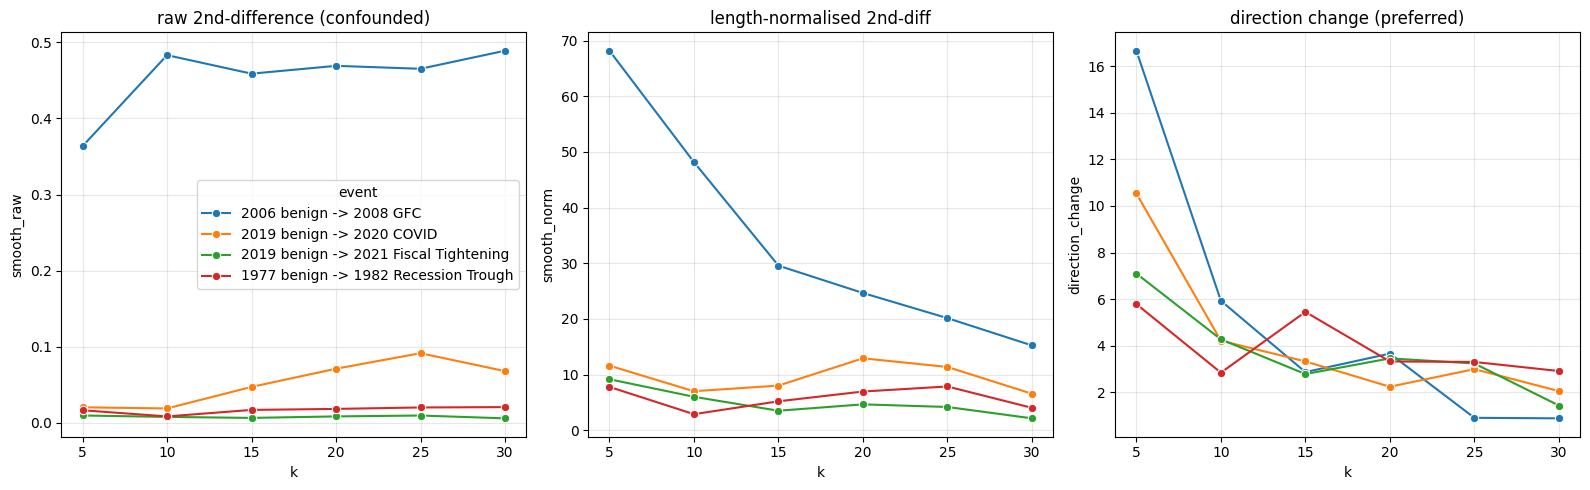


Monotone decrease in direction_change with k (per event):
  2006 benign -> 2008 GFC            [16.677  5.925  2.858  3.653  0.891  0.869]  strictly_down=False
  2019 benign -> 2020 COVID          [10.538  4.206  3.317  2.229  2.985  2.041]  strictly_down=False
  2019 benign -> 2021 Fiscal Tighten [7.095 4.266 2.773 3.447 3.228 1.421]  strictly_down=False
  1977 benign -> 1982 Recession Trou [5.782 2.834 5.445 3.316 3.293 2.903]  strictly_down=False


In [18]:
# [F4] show raw vs normalised vs direction_change side by side
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,metric,ttl in zip(axes,["smooth_raw","smooth_norm","direction_change"],
                         ["raw 2nd-difference (confounded)","length-normalised 2nd-diff","direction change (preferred)"]):
    sns.lineplot(data=res,x="k",y=metric,hue="event",marker="o",palette="tab10",ax=ax,legend=(metric=="smooth_raw"))
    ax.set_title(ttl); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("\nMonotone decrease in direction_change with k (per event):")
for ev in res["event"].unique():
    v=res[res["event"]==ev].sort_values("k")["direction_change"].values
    print(f"  {ev[:34]:34s} {np.round(v,3)}  strictly_down={bool(np.all(np.diff(v)<0))}")